# Importance sampling

Importance sampling rewrites an expectation under a target $p$ using draws from a proposal $q$. It can turn a rare event into an ordinary event—but only if the proposal covers the target support and the weights remain usable.

We will distinguish standard IS from self-normalized IS, inspect log weights and ESS, reproduce the Gaussian-tail CLI experiment, and expose exponential weight collapse in product spaces. See the [importance sampling guide](../methods/importance_sampling.md) for the compact formulas.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np

import sampler_lab
from sampler_lab import spawn_rngs

warnings.filterwarnings("error")
warnings.filterwarnings("ignore", category=PendingDeprecationWarning, module="ipykernel")
QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
MODE = "quick" if QUICK_MODE else "publication"
plt.rcParams.update({"figure.dpi": 105, "figure.figsize": (7.2, 4.3)})
FIGURE_COUNT = 0
print(f"sampler-lab {sampler_lab.__version__} | execution mode: {MODE}")

from sampler_lab.diagnostics import weight_diagnostics
from sampler_lab.exact import box_muller
from sampler_lab.importance import (
    chi_squared_divergence_estimate,
    gaussian_product_log_weights,
    gaussian_scale_chi_squared,
    gaussian_tail_experiment,
    gaussian_weight_collapse_experiment,
    log_importance_weights,
    product_chi_squared,
    renyi_divergence_order_two_estimate,
    self_normalized_importance_estimate,
    standard_importance_estimate,
    standard_normal_upper_tail,
)

sampler-lab 0.12.0 | execution mode: publication


## Minimal standard and self-normalized estimates

For normalized $p$ and $q$,

$$\widehat\mu_{\rm IS}=\frac1N\sum_i \frac{p(X_i)}{q(X_i)}f(X_i)$$

is unbiased under the usual integrability conditions. When only an unnormalized target is known,

$$\widehat\mu_{\rm SNIS}=\frac{\sum_i w_i f(X_i)}{\sum_i w_i}$$

is a ratio estimator and generally biased at finite $N$.

Here $p=N(0,1)$, $q=N(1,1)$, and $f(x)=x^2$, whose target expectation is one.

In [2]:
n = 5000 if QUICK_MODE else 30000
proposal_rng = spawn_rngs(202221, 1)[0]
samples = box_muller(proposal_rng, n) + 1.0
log_two_pi = np.log(2 * np.pi)


def log_target(point):
    x = float(point)
    return -0.5 * (log_two_pi + x * x)


def log_proposal(point):
    x = float(point)
    return -0.5 * (log_two_pi + (x - 1.0) ** 2)


log_weights = log_importance_weights(samples, log_target, log_proposal)
standard = standard_importance_estimate(samples, log_weights, observable=lambda x: x**2)
self_normalized = self_normalized_importance_estimate(
    samples, log_weights, observable=lambda x: x**2
)
diagnostics = weight_diagnostics(log_weights)
print("standard IS:", standard)
print("self-normalized IS:", self_normalized)
print("weight diagnostics:", diagnostics)

standard IS: ImportanceEstimate(value=0.9830467945227122, standard_error=0.026361901494790323, n_samples=30000, effective_sample_size=11247.946831889703, max_normalized_weight=0.00116241625153167, weight_entropy=9.81546055151972, log_mean_weight=0.0006924556604221976, delta_method_bias=None, self_normalized=False)
self-normalized IS: ImportanceEstimate(value=0.9823663138339276, standard_error=0.022037252861561503, n_samples=30000, effective_sample_size=11247.946831889703, max_normalized_weight=0.00116241625153167, weight_entropy=9.81546055151972, log_mean_weight=0.0006924556604221976, delta_method_bias=-7.874688842034765e-05, self_normalized=True)
weight diagnostics: WeightDiagnostics(effective_sample_size=11247.946831889703, ess_fraction=0.37493156106299014, max_normalized_weight=0.00116241625153167, entropy=9.81546055151972, normalized_entropy=0.9521297531020256, perplexity=18314.723011653696, coefficient_of_variation_squared=1.6671534323886799, n_positive=30000, n_weights=30000)


Before plotting, predict the shape: the proposal is shifted right, so samples far to the left receive larger weights. The log-weight histogram should therefore have a long upper tail tied to atypical proposal draws.

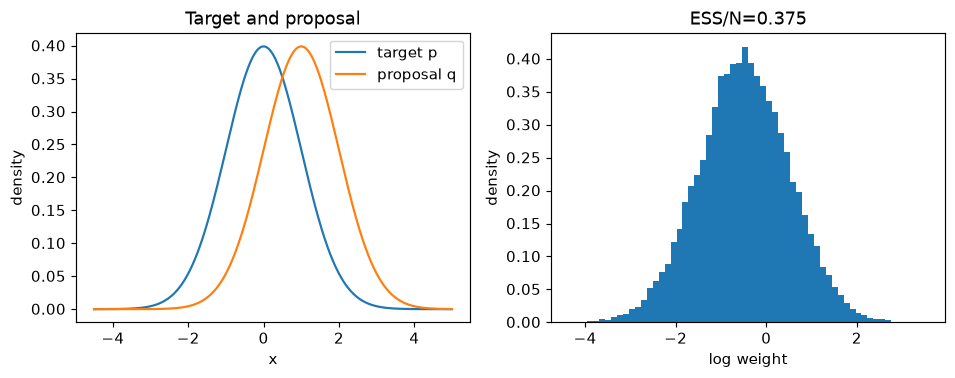

In [3]:
x_grid = np.linspace(-4.5, 5.0, 500)
target_density = np.exp(-0.5 * x_grid**2) / np.sqrt(2 * np.pi)
proposal_density = np.exp(-0.5 * (x_grid - 1.0) ** 2) / np.sqrt(2 * np.pi)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7))
axes[0].plot(x_grid, target_density, label="target p")
axes[0].plot(x_grid, proposal_density, label="proposal q")
axes[0].set(xlabel="x", ylabel="density", title="Target and proposal")
axes[0].legend()
axes[1].hist(log_weights, bins=60, density=True)
axes[1].set(xlabel="log weight", ylabel="density", title=f"ESS/N={diagnostics.ess_fraction:.3f}")
fig.tight_layout()
plt.show()
plt.close(fig)
FIGURE_COUNT += 1

## Rare Gaussian tails

For $p=N(0,1)$, $q=N(\mu,1)$, and the event $X\ge a$,

$$\log\frac{p(x)}{q(x)}=-\mu x+\frac{\mu^2}{2}.$$

We reproduce the console demo defaults: seed 2022, threshold 4, and proposal means $0,2,4$. Crude Monte Carlo may see almost no events; shifting toward the threshold should sharply reduce relative standard error.

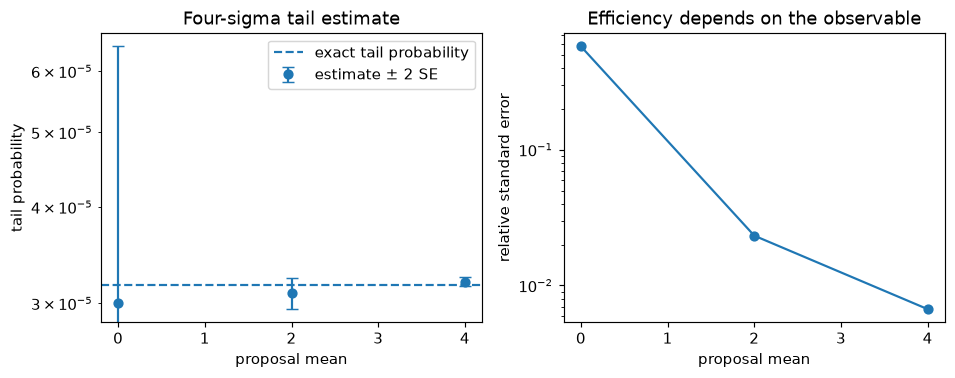

GaussianTailRow(proposal_mean=0.0, estimate=3e-05, truth=3.1671241833119965e-05, standard_error=1.732033486800989e-05, relative_standard_error=0.5773444956003297, absolute_error=1.6712418331199642e-06, event_count=3, effective_sample_size=100000.00000000025, max_normalized_weight=1e-05)
GaussianTailRow(proposal_mean=2.0, estimate=3.092882117740855e-05, truth=3.1671241833119965e-05, standard_error=7.19921370385526e-07, relative_standard_error=0.023276715470532734, absolute_error=7.424206557114161e-07, event_count=2228, effective_sample_size=3097.013661147378, max_normalized_weight=0.007053351147134253)
GaussianTailRow(proposal_mean=4.0, estimate=3.198914357007243e-05, truth=3.1671241833119965e-05, standard_error=2.1413125949135467e-07, relative_standard_error=0.006693872845401401, absolute_error=3.17901736952466e-07, event_count=50086, effective_sample_size=1.9857817822252815, max_normalized_weight=0.7085300651508798)


In [4]:
tail_n = 12000 if QUICK_MODE else 100000
tail_rows = gaussian_tail_experiment(
    spawn_rngs(2022, 2)[0], threshold=4.0, n_samples=tail_n, proposal_means=[0.0, 2.0, 4.0]
)
means = np.array([row.proposal_mean for row in tail_rows])
estimates = np.array([row.estimate for row in tail_rows])
ses = np.array([row.standard_error for row in tail_rows])
relative_ses = np.array([row.relative_standard_error for row in tail_rows])
truth = standard_normal_upper_tail(4.0)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7))
axes[0].errorbar(means, estimates, yerr=2 * ses, fmt="o", capsize=4, label="estimate ± 2 SE")
axes[0].axhline(truth, linestyle="--", label="exact tail probability")
axes[0].set(
    xlabel="proposal mean",
    ylabel="tail probability",
    yscale="log",
    title="Four-sigma tail estimate",
)
axes[0].legend()
axes[1].plot(means, relative_ses, "o-")
axes[1].set(
    xlabel="proposal mean",
    ylabel="relative standard error",
    yscale="log",
    title="Efficiency depends on the observable",
)
fig.tight_layout()
plt.show()
plt.close(fig)
FIGURE_COUNT += 1
for row in tail_rows:
    print(row)

## Sorted-weight concentration

Weight ESS is global: it measures concentration in the weights, not the variance of one special observable. A proposal centered at the event can have severe global weight concentration while still estimating the event probability efficiently.

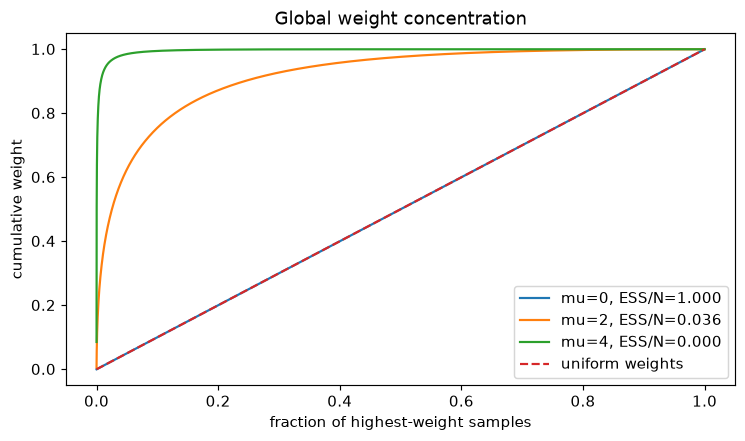

In [5]:
concentration_rngs = spawn_rngs(202222, 3)
fig, ax = plt.subplots()
weight_ess = []
for generator, mu in zip(concentration_rngs, [0.0, 2.0, 4.0], strict=True):
    x = box_muller(generator, tail_n) + mu
    lw = -mu * x + 0.5 * mu**2
    diag = weight_diagnostics(lw)
    weight_ess.append(diag.ess_fraction)
    w = np.exp(lw - lw.max())
    w /= w.sum()
    curve = np.cumsum(np.sort(w)[::-1])
    ax.plot(
        np.arange(1, tail_n + 1) / tail_n, curve, label=f"mu={mu:g}, ESS/N={diag.ess_fraction:.3f}"
    )
ax.plot([0, 1], [0, 1], "--", label="uniform weights")
ax.set(
    xlabel="fraction of highest-weight samples",
    ylabel="cumulative weight",
    title="Global weight concentration",
)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)
FIGURE_COUNT += 1

## Product-space collapse

For $p=N(0,I_d)$ and $q=N(0,1.25^2 I_d)$, even the mild one-dimensional mismatch compounds across coordinates. The exact identity

$$1+\chi^2(p\Vert q)=\left(\frac{\sigma_q^2}{\sigma_p\sqrt{2\sigma_q^2-\sigma_p^2}}\right)^d$$

predicts an exponentially shrinking asymptotic ESS fraction $1/(1+\chi^2)$.

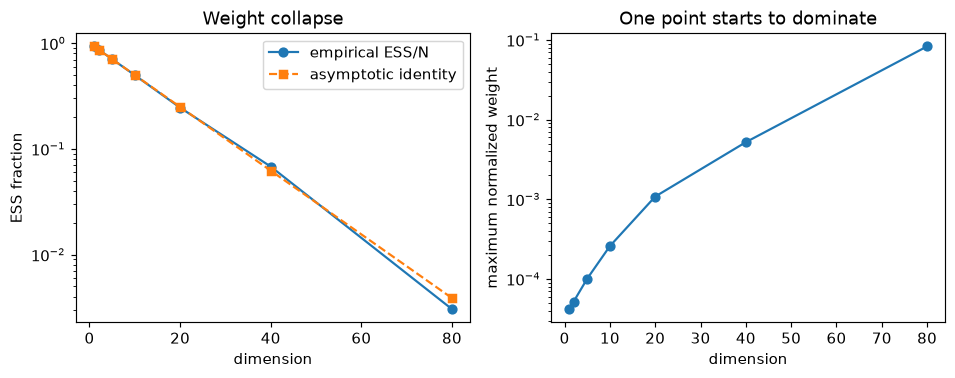

In [6]:
dimensions = [1, 2, 5, 10, 20, 40] if QUICK_MODE else [1, 2, 5, 10, 20, 40, 80]
collapse_n = 6000 if QUICK_MODE else 30000
collapse_rows = gaussian_weight_collapse_experiment(
    spawn_rngs(2022, 2)[1], dimensions, collapse_n, proposal_scale=1.25
)
dims = np.array([row.dimension for row in collapse_rows])
emp = np.array([row.ess_fraction for row in collapse_rows])
theory = np.array([row.asymptotic_ess_fraction for row in collapse_rows])
maxw = np.array([row.max_normalized_weight for row in collapse_rows])
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7))
axes[0].semilogy(dims, emp, "o-", label="empirical ESS/N")
axes[0].semilogy(dims, theory, "s--", label="asymptotic identity")
axes[0].set(xlabel="dimension", ylabel="ESS fraction", title="Weight collapse")
axes[0].legend()
axes[1].semilogy(dims, maxw, "o-")
axes[1].set(
    xlabel="dimension", ylabel="maximum normalized weight", title="One point starts to dominate"
)
fig.tight_layout()
plt.show()
plt.close(fig)
FIGURE_COUNT += 1

## Controlled failure: infinite second moment

If the Gaussian proposal is too narrow, $2\sigma_q^2\le\sigma_p^2$, then $\chi^2(p\Vert q)=\infty$. A finite run still returns a finite number—an especially treacherous failure because the estimator can appear calm until a rare huge weight arrives.

In [7]:
infinite_chi2 = gaussian_scale_chi_squared(1, target_scale=1.0, proposal_scale=0.6)
finite_chi2 = gaussian_scale_chi_squared(1, target_scale=1.0, proposal_scale=1.25)
empirical_chi2 = chi_squared_divergence_estimate(log_weights)
renyi2 = renyi_divergence_order_two_estimate(log_weights)
probe = 1.25 * box_muller(spawn_rngs(202224, 1)[0], 400).reshape(200, 2)
probe_log_weights = gaussian_product_log_weights(probe, target_scale=1.0, proposal_scale=1.25)
single_factor_chi2 = gaussian_scale_chi_squared(1, target_scale=1.0, proposal_scale=1.25)
product_identity_error = abs(
    product_chi_squared(single_factor_chi2, 5)
    - gaussian_scale_chi_squared(5, target_scale=1.0, proposal_scale=1.25)
)
print(f"chi^2 for proposal scale 0.6: {infinite_chi2}")
print(f"chi^2 for proposal scale 1.25: {finite_chi2:.4f}")
print(f"shifted-example empirical chi^2={empirical_chi2:.4f}; Renyi-2={renyi2:.4f}")

chi^2 for proposal scale 0.6: inf
chi^2 for proposal scale 1.25: 0.0719
shifted-example empirical chi^2=1.6672; Renyi-2=0.9810


## When to use importance sampling

Use it when sampling from a proposal is easy, target/proposal log densities are available up to compatible normalizations, and the proposal deliberately covers regions important to the observable. Avoid trusting a point estimate without weight diagnostics, repeated runs, and a support/second-moment argument.

Further experiments: optimize the Gaussian tail shift over a fine grid; compare standard and self-normalized bias over repeated runs; or hold total random-number cost fixed while dimension grows.

In [8]:
assert abs(standard.value - 1.0) < (0.16 if QUICK_MODE else 0.07)
assert abs(self_normalized.value - 1.0) < (0.12 if QUICK_MODE else 0.05)
assert tail_rows[-1].relative_standard_error < tail_rows[0].relative_standard_error
assert emp[-1] < emp[0]
assert theory[-1] < theory[0]
assert np.isinf(infinite_chi2)
assert np.isclose(renyi2, np.log1p(empirical_chi2))
assert probe_log_weights.shape == (200,)
assert np.all(np.isfinite(probe_log_weights))
assert product_identity_error < 1e-12
EXPECTED_FIGURES = 4
assert FIGURE_COUNT == EXPECTED_FIGURES
print(f"Notebook checks passed; expected figures: {EXPECTED_FIGURES}")

Notebook checks passed; expected figures: 4
